In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from statsmodels.tsa.seasonal import seasonal_decompose
from matplotlib.ticker import MultipleLocator
# from fbprophet import Prophet

train_csv_path = "data/train.csv"
train = pd.read_csv(train_csv_path)

test_csv_path = "data/test.csv"
test = pd.read_csv(test_csv_path)

In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
train['date'] = pd.to_datetime(train['date'])
train['day'] = train['date'].dt.day
train['month'] = train['date'].dt.month
train['year'] = train['date'].dt.year
train['date'] = pd.to_datetime(train['date'])
train['day_of_week'] = train['date'].dt.weekday
train['week_of_year'] = train['date'].dt.isocalendar().week.astype(int)
train['quarter'] = train['date'].dt.quarter
train['day_of_year'] = train['date'].dt.dayofyear

# Cycle need to check the seasonality decompose
train['month_sin'] = np.sin(2 * np.pi * train['month'] / 12)
train['month_cos'] = np.cos(2 * np.pi * train['month'] / 12)

# Adding 2-day seasonality columns
# train['day_cycle'] = (train['date'].dt.day % 2)  # This will give a repeating pattern of [0, 1, 0, 1, ...]
# train['two_day_sin'] = np.sin(2 * np.pi * train['day_cycle'] / 2)
# train['two_day_cos'] = np.cos(2 * np.pi * train['day_cycle'] / 2)

# Drop 'day_cycle' as it's no longer needed
# train.drop('day_cycle', axis=1, inplace=True)

# Adding 7-day seasonality columns
train['week_sin'] = np.sin(2 * np.pi * train['day_of_week'] / 7)
train['week_cos'] = np.cos(2 * np.pi * train['day_of_week'] / 7)

# Lag need to check the autocorrelation
# Adding lags because I think SARIMA might neglected some lags (residuals having seasons, patterns)
train['sales_lag_7'] = train['sales'].shift(7)
train['sales_lag_365'] = train['sales'].shift(365)

In [3]:
# --- [CELL 2]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
# Filter for a specific store-item combination, say store 1 and item 1
train_subset = train[(train['store'] == 8) & (train['item'] == 20)]
train_subset.set_index('date', inplace=True)
train_subset.index.freq = 'D'
train_subset.head()

,store,item,sales,day,month,year,day_of_week,week_of_year,quarter,day_of_year,month_sin,month_cos,week_sin,week_cos,sales_lag_7,sales_lag_365
date,,,,,,,,,,,,,,,,
2013-01-01,8,20,27,1,1,2013,1,1,1,1,0.5,0.866025,0.781831,0.623490,26.0,34.0
2013-01-02,8,20,34,2,1,2013,2,1,1,2,0.5,0.866025,0.974928,-0.222521,23.0,21.0
2013-01-03,8,20,25,3,1,2013,3,1,1,3,0.5,0.866025,0.433884,-0.900969,28.0,25.0
2013-01-04,8,20,44,4,1,2013,4,1,1,4,0.5,0.866025,-0.433884,-0.900969,19.0,19.0
2013-01-05,8,20,37,5,1,2013,5,1,1,5,0.5,0.866025,-0.974928,-0.222521,28.0,40.0


In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
sarima_data = train_subset[['sales']]

print(sarima_data.index)
sarima_data.head()

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06', '2013-01-07', '2013-01-08',
               '2013-01-09', '2013-01-10',
               ...
               '2017-12-22', '2017-12-23', '2017-12-24', '2017-12-25',
               '2017-12-26', '2017-12-27', '2017-12-28', '2017-12-29',
               '2017-12-30', '2017-12-31'],
              dtype='datetime64[ns]', name='date', length=1826, freq='D')


,sales
date,
2013-01-01,27
2013-01-02,34
2013-01-03,25
2013-01-04,44
2013-01-05,37


In [5]:
# --- [CELL 4]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
# Data Splitting
train_end_date = '2017-09-30'
pred_start_date = '2017-10-01'
pred_end_date = '2017-12-31'

y_train = sarima_data.loc[:train_end_date, 'sales']
y_val = sarima_data.loc[pred_start_date:pred_end_date, 'sales']

exog_columns = ['year','day_of_week', 'month_cos']
# So far 3 of these has highest corr with sales

exog_train = train_subset.loc[:train_end_date, exog_columns]
exog_val = train_subset.loc[pred_start_date:pred_end_date, exog_columns]

# Model Parameters
p, d, q = 1, 1, 1
P, D, Q, s = 1, 1, 1, 7
# d - number of times to difference it to become stationary
# Model Training with exogenous variables
# For instance, if the PACF shuts off (i.e., values become very close to zero) after 2 lags, then p=2
# For example, if the ACF cuts off after 1 lag, then q=1
model = SARIMAX(y_train, exog=exog_train, order=(p, d, q), seasonal_order=(P, D, Q, s))
results = model.fit(maxiter=150, disp=-1) # Iterations of the optimizer

# Forecasting with exogenous variables
y_pred = results.predict(start=pd.Timestamp(pred_start_date), end=pd.Timestamp(pred_end_date), exog=exog_val, dynamic=False)

# Model Evaluation
rmse = mean_squared_error(y_val, y_pred, squared=False)
print(f'RMSE: {rmse}')

RMSE: 9.775121767444054


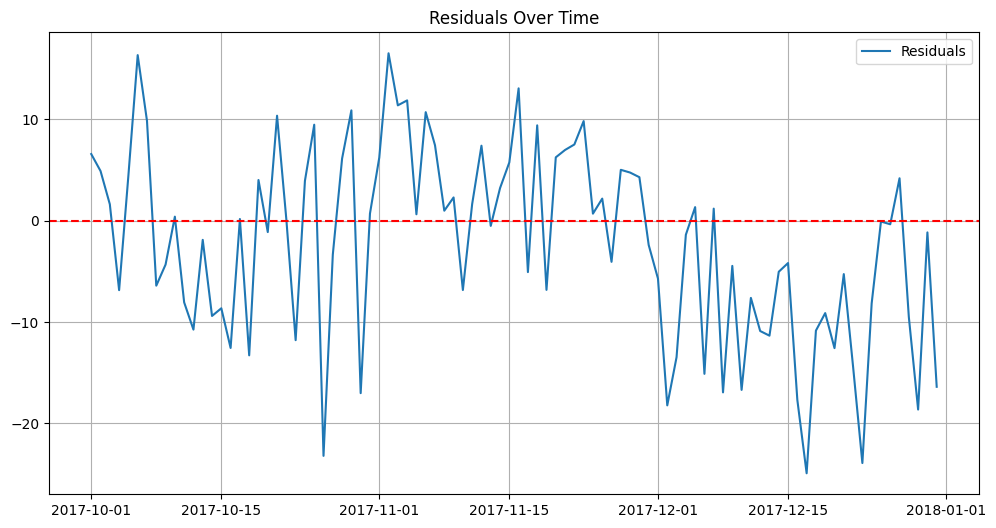

In [6]:
# --- [CELL 5]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 6}
residuals = y_val - y_pred
plt.figure(figsize=(12, 6))
plt.plot(residuals.index, residuals, label='Residuals')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals Over Time')
plt.grid(True)
plt.legend()
plt.show()

<Figure size 1200x600 with 0 Axes>

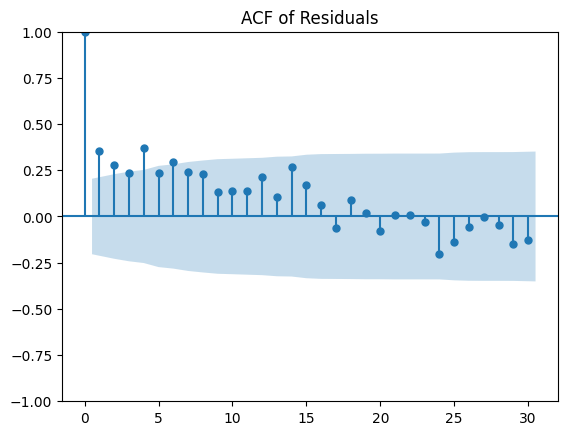

<Figure size 1200x600 with 0 Axes>

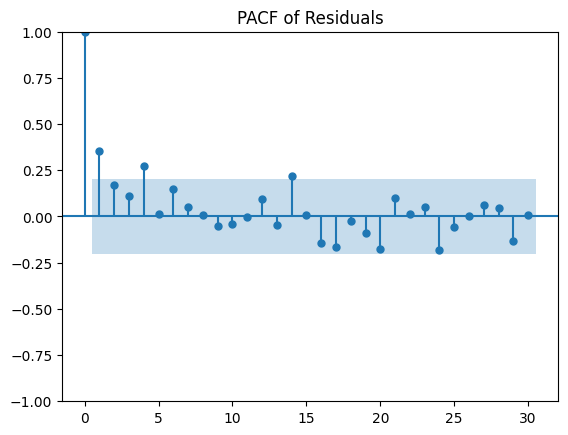

In [7]:
# --- [CELL 6]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 7}
# === BEFORE (original) ===
# from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# 
# plt.figure(figsize=(12, 6))
# plot_acf(residuals, lags=180, title='ACF of Residuals')
# plt.show()
# 
# plt.figure(figsize=(12, 6))
# plot_pacf(residuals, lags=180, title='PACF of Residuals')
# plt.show()
# 
# # Ideal: no significant autocorrelation
# # Ideally, for a well-fitted model, the autocorrelations for all lags should fall within the blue shaded region (the confidence intervals). If any spikes exceed this area, it suggests that there's some pattern in the residuals at that particular lag that the model hasn't captured.

# === AFTER (edited) ===
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12, 6))
plot_acf(residuals, lags=30, title='ACF of Residuals')
plt.show()

plt.figure(figsize=(12, 6))
plot_pacf(residuals, lags=30, title='PACF of Residuals')
plt.show()

In [1]:
# manual inspection results
if_pass = False
assert if_pass, "Manual inspection failed."

AssertionError: Manual inspection failed.